In [271]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 26})
plt.rcParams['axes.grid'] = False
import matplotlib as mpl
mpl.rcParams['font.family'] = 'monospace' 
from scipy.ndimage import gaussian_filter
from matplotlib.colors import LogNorm
import matplotlib.ticker as ticker
from matplotlib.colors import Normalize
import sys
import os
sys.path.append(os.path.abspath('..'))
from scripts import analysis_utils as au
import importlib
importlib.reload(au)
from scipy.special import erf

In [272]:
data_1 = np.concatenate((np.loadtxt('single_day_20260402_results.txt'),
                         np.loadtxt('single_day_2026_04_05_injections.txt'),
                         np.loadtxt('single_day_2026_04_08_injections.txt'),
                         np.loadtxt('single_day_2026_04_11_injections.txt'),
                         np.loadtxt('single_day_2026_04_14_injections.txt'),
                         np.loadtxt('1_day_injections.txt')))

syn_data_1 = np.loadtxt('synthetic_map_no_tsky.txt')
print(f'Number of pointings: {len(np.unique(data_1[:, 0:2], axis=0))}')
print(f'Number of days: {len(np.unique(data_1[:, 2]))}')
print(f'Total fraction of recovered injections: {(100*len(data_1[data_1[:, -1] > 0.])/len(data_1)):.2f}%')
print(f'Number of injections: {len(data_1)}')
print('------------------------')
syn_f_idx = 1
syn_DM_idx = 2
syn_S_idx = 3
syn_FWHM_idx = 4
syn_sigma_idx = 5
syn_nharm_idx = 6
print('Synthetic map:')
print(f'Total fraction of recovered injections: \
    {(100*len(syn_data_1[syn_data_1[:, syn_sigma_idx] > 6.])/len(syn_data_1)):.2f}%')
print(f'Number of injections: {len(syn_data_1)}')

RA_idx = 0
Dec_idx = 1
f_idx = 4
DM_idx = 5
S_idx = 6
FWHM_idx = 7
sigma_idx = 8

# TPA_idx = data_1[:, 3].astype('int')
# FWHM_array = np.load('../profiles/TPA_fwhm.npy')
# FWHM = FWHM_array[TPA_idx]
# jitter = np.random.uniform(0.85, 1.15, size=len(FWHM)) #to deal with discrete FWHM
# data_1[:, FWHM_idx] = FWHM * jitter

from astropy.coordinates import SkyCoord
from astropy import units as u
coords = SkyCoord(ra=data_1[:, RA_idx]*u.deg, dec=data_1[:, Dec_idx]*u.deg, frame='icrs')
b1 = coords.galactic.b


Number of pointings: 5509
Number of days: 6
Total fraction of recovered injections: 27.42%
Number of injections: 56516
------------------------
Synthetic map:
Total fraction of recovered injections:     36.53%
Number of injections: 24446


In [273]:
fglob_mask_1 = (data_1[:, f_idx] > 0.1) & (data_1[:, f_idx] < 250.)
DMglob_mask_1 = (data_1[:, DM_idx] > 1.) & (data_1[:, DM_idx] < 600.)
Sglob_mask_1 = data_1[:, S_idx] > 0.1
glob_mask_1 = fglob_mask_1 & DMglob_mask_1 & Sglob_mask_1

syn_fglob_mask_1 = (syn_data_1[:, f_idx] > 0.1) & (syn_data_1[:, f_idx] < 250.)
syn_DMglob_mask_1 = (syn_data_1[:, DM_idx] > 1.) & (syn_data_1[:, DM_idx] < 600.)
syn_Sglob_mask_1 = syn_data_1[:, S_idx] > 0.1
syn_glob_mask_1 = syn_fglob_mask_1 & syn_DMglob_mask_1 & syn_Sglob_mask_1

In [326]:
f_bins = np.logspace(-3, 2.7, 250)
f_dev = 10
DM_bins = np.linspace(0, 200, 150)
DM_dev = 5
S_bins = np.logspace(-2, 1, 250)
S_dev = 10
FWHM_bins = np.logspace(np.log10(0.005), np.log10(0.15), 250)
FWHM_dev = 10
RA_bins = np.linspace(0, 360, 250)
RA_dev = 10
Dec_bins = np.linspace(min(data_1[:, Dec_idx]), max(data_1[:, Dec_idx]), 500)
Dec_dev = 30

In [327]:
f_inj_p_smooth, f_sens, f_sens_smooth = au.get_sensitivity(
    data_1[DMglob_mask_1 & Sglob_mask_1], 
    *(f_idx, f_bins, f_dev)
)

DM_inj_p_smooth, DM_sens, DM_sens_smooth = au.get_sensitivity(
    data_1[fglob_mask_1 & Sglob_mask_1],
    *(DM_idx, DM_bins, DM_dev)
)


S_inj_p_smooth, S_sens, S_sens_smooth = au.get_sensitivity(
    data_1[fglob_mask_1 & DMglob_mask_1],
    *(S_idx, S_bins, S_dev)
)


FWHM_inj_p_smooth, FWHM_sens, FWHM_sens_smooth = au.get_sensitivity(
    data_1[fglob_mask_1 & DMglob_mask_1 & Sglob_mask_1],
    *(FWHM_idx, FWHM_bins, FWHM_dev)
)


RA_inj_p_smooth, RA_sens, RA_sens_smooth = au.get_sensitivity(
    data_1[fglob_mask_1 & DMglob_mask_1 & Sglob_mask_1],
    *(RA_idx, RA_bins, RA_dev)
)



Dec_inj_p_smooth, Dec_sens, Dec_sens_smooth = au.get_sensitivity(
    data_1[fglob_mask_1 & DMglob_mask_1 & Sglob_mask_1],
    *(Dec_idx, Dec_bins, Dec_dev)
)

_, f_pred, f_pred_smooth = au.get_sensitivity(
    syn_data_1[syn_DMglob_mask_1 & syn_Sglob_mask_1], 
    predicted = True,
    *(syn_f_idx, f_bins, f_dev)
)

_, DM_pred, DM_pred_smooth = au.get_sensitivity(
    syn_data_1[syn_fglob_mask_1 & syn_Sglob_mask_1],
    predicted = True,
    *(syn_DM_idx, DM_bins, DM_dev)
)


_, S_pred, S_pred_smooth = au.get_sensitivity(
    syn_data_1[syn_fglob_mask_1 & syn_DMglob_mask_1],
    predicted = True,
    *(syn_S_idx, S_bins, S_dev)
)


_, FWHM_pred, FWHM_pred_smooth = au.get_sensitivity(
    syn_data_1[syn_glob_mask_1],
    predicted = True,
    *(syn_FWHM_idx, FWHM_bins, FWHM_dev)
)


_, RA_pred, RA_pred_smooth = au.get_sensitivity(
    syn_data_1[syn_glob_mask_1],
    predicted = True,
    *(RA_idx, RA_bins, RA_dev)
)



_, Dec_pred, Dec_pred_smooth = au.get_sensitivity(
    syn_data_1[syn_glob_mask_1],
    predicted = True,
    *(Dec_idx, Dec_bins, Dec_dev)
)

sigma_mask = data_1[:, sigma_idx] >= 6. 

f_sigma_1, f_comp, f_comp_smooth = au.get_sensitivity(
    data_1[sigma_mask], 
    *(f_idx, f_bins, f_dev)
)

DM_sigma_1, DM_comp, DM_comp_smooth = au.get_sensitivity(
    data_1[sigma_mask],
    *(DM_idx, DM_bins, DM_dev)
)


S_sigma_1, S_comp, S_comp_smooth = au.get_sensitivity(
    data_1[sigma_mask],
    *(S_idx, S_bins, S_dev)
)


FWHM_sigma_1, FWHM_comp, FWHM_comp_smooth = au.get_sensitivity(
    data_1[sigma_mask],
    *(FWHM_idx, FWHM_bins, FWHM_dev)
)


RA_sigma_1, RA_comp, RA_comp_smooth = au.get_sensitivity(
    data_1[sigma_mask],
    *(RA_idx, RA_bins, RA_dev)
)


Dec_sigma_1, Dec_comp, Dec_comp_smooth = au.get_sensitivity(
    data_1[sigma_mask],
    *(Dec_idx, Dec_bins, Dec_dev)
)


/data1/people/rsquillace/Transmissivity/scripts/analysis_utils.py:35: RuntimeWarning: invalid value encountered in divide
  
/data1/people/rsquillace/Transmissivity/scripts/analysis_utils.py:33: RuntimeWarning: invalid value encountered in divide
  


In [328]:
import importlib
importlib.reload(au)

<module 'scripts.analysis_utils' from '/data1/people/rsquillace/Transmissivity/scripts/analysis_utils.py'>

In [329]:
f_var = np.var(f_sens_smooth)
DM_var = np.var(DM_sens_smooth)
S_var = np.var(S_sens_smooth)
FWHM_var = np.var(FWHM_sens_smooth)
RA_var = np.var(RA_sens_smooth)
Dec_var = np.var(Dec_sens_smooth)

params = ['f', 'DM', 'S', 'FWHM', 'RA', 'Dec']
vars = [f_var, DM_var, S_var, FWHM_var, RA_var, Dec_var]
sorted_var_mask = np.argsort(vars)

print('Standard deviation with parameter:')
print('---------------------------------')
for i in sorted_var_mask[::-1]:
    print(f'{params[i]}: {np.sqrt(vars[i]):.3f}')

Standard deviation with parameter:
---------------------------------
S: 0.395
f: 0.220
FWHM: 0.164
DM: 0.097
Dec: 0.080
RA: 0.025


In [330]:
mask = data_1[:, FWHM_idx] > 0.15
sigma_mask = data_1[:, -1] > 0
print(f'{100* len(data_1[mask & sigma_mask]) / len(data_1[mask]):.1f}%')

10.1%


In [331]:
data_stack = np.concatenate((
                        np.unique(np.loadtxt('29_day_injections.txt'), axis = 0),
                        np.unique(np.loadtxt('30_day_injections.txt'), axis = 0)
                        )
                        )
print(f'Number of pointings: {len(np.unique(data_stack[:, 0:2], axis=0))}')
print(f'Total fraction of recovered injections: {(100*len(data_stack[data_stack[:, -1] > 0.])/len(data_stack)):.2f}%')
print(f'Number of injections: {len(data_stack)}')
RA = data_stack[:, 0]
Dec = data_stack[:, 1]
f = data_stack[:, 4]
DM = data_stack[:, 5]
S = data_stack[:, 6]
fwhm = data_stack[:, 7]
coords = SkyCoord(ra=data_stack[:, RA_idx]*u.deg, dec=data_stack[:, Dec_idx]*u.deg, frame='icrs')
b13 = coords.galactic.b

Number of pointings: 2480
Total fraction of recovered injections: 39.92%
Number of injections: 22545


In [332]:
fglob_mask_stack = (data_stack[:, f_idx] > 0.1) & (data_stack[:, f_idx] < 250.)
DMglob_mask_stack = (data_stack[:, DM_idx] > 1.) & (data_stack[:, DM_idx] < 600.)
Sglob_mask_stack = data_stack[:, S_idx] > 0.1
glob_mask_stack = fglob_mask_stack & DMglob_mask_stack & Sglob_mask_stack

In [333]:
print('---SINGLE DAY---')
retrieved_mask = data_1[:, -1] > 0
print(f'Overall retrieval rate: {len(data_1[glob_mask_1 & retrieved_mask]) / len(data_1[glob_mask_1]):.3f}')
low_freq_mask = data_1[:, 4] < 0.05
print(f'Retrieved {len(data_1[low_freq_mask & DMglob_mask_1 & Sglob_mask_1 & retrieved_mask]) / len(data_1[low_freq_mask & DMglob_mask_1 & Sglob_mask_1]):.3f} of injections with f < 0.05 Hz.')
lowish_freq_mask = data_1[:, 4] < 0.1
print(f'Retrieved {len(data_1[lowish_freq_mask & DMglob_mask_1 & Sglob_mask_1 & retrieved_mask]) / len(data_1[lowish_freq_mask & DMglob_mask_1 & Sglob_mask_1]):.3f} of injections with f < 0.1 Hz.')
mid_freq_mask = data_1[:, 4] < 1
print(f'Retrieved {len(data_1[mid_freq_mask & DMglob_mask_1 & Sglob_mask_1 & retrieved_mask]) / len(data_1[mid_freq_mask & DMglob_mask_1 & Sglob_mask_1]):.3f} of injections with f < 1 Hz.')
hi_freq_mask = data_1[:, 4] > 100
print(f'Retrieved {len(data_1[hi_freq_mask & DMglob_mask_1 & Sglob_mask_1 & retrieved_mask]) / len(data_1[hi_freq_mask & DMglob_mask_1 & Sglob_mask_1]):.3f} of injections with f > 100 Hz.')
low_flux_mask = data_1[:, 6] < 0.1
print(f'Retrieved {len(data_1[low_flux_mask & DMglob_mask_1 & fglob_mask_1 & retrieved_mask]) / len(data_1[low_flux_mask & DMglob_mask_1 & fglob_mask_1]):.3f} of injections with S < 0.1 mJy')

print('\n---MONTHLY STACK---')
retrieved_mask = data_stack[:, -1] > 0
print(f'Overall retrieval rate: {len(data_stack[glob_mask_stack & retrieved_mask]) / len(data_stack[glob_mask_stack]):.3f}')
low_freq_mask = data_stack[:, 4] < 0.05
print(f'Retrieved {len(data_stack[low_freq_mask & DMglob_mask_stack & Sglob_mask_stack & retrieved_mask]) / len(data_stack[low_freq_mask & DMglob_mask_stack & Sglob_mask_stack]):.3f} of injections with f < 0.05 Hz.')
lowish_freq_mask = data_stack[:, 4] < 0.1
print(f'Retrieved {len(data_stack[lowish_freq_mask & DMglob_mask_stack & Sglob_mask_stack & retrieved_mask]) / len(data_stack[lowish_freq_mask & DMglob_mask_stack & Sglob_mask_stack]):.3f} of injections with f < 0.1 Hz.')
mid_freq_mask = data_stack[:, 4] < 1
print(f'Retrieved {len(data_stack[mid_freq_mask & DMglob_mask_stack & Sglob_mask_stack & retrieved_mask]) / len(data_stack[mid_freq_mask & DMglob_mask_stack & Sglob_mask_stack]):.3f} of injections with f < 1 Hz.')
hi_freq_mask = data_stack[:, 4] > 100
print(f'Retrieved {len(data_stack[hi_freq_mask & DMglob_mask_stack & Sglob_mask_stack & retrieved_mask]) / len(data_stack[hi_freq_mask & DMglob_mask_stack & Sglob_mask_stack]):.3f} of injections with f > 100 Hz.')
low_flux_mask = data_stack[:, 6] < 0.1
print(f'Retrieved {len(data_stack[low_flux_mask & DMglob_mask_stack & fglob_mask_stack & retrieved_mask]) / len(data_stack[low_flux_mask & DMglob_mask_stack & fglob_mask_stack]):.3f} of injections with S < 0.1 mJy')


---SINGLE DAY---
Overall retrieval rate: 0.539
Retrieved 0.049 of injections with f < 0.05 Hz.
Retrieved 0.088 of injections with f < 0.1 Hz.
Retrieved 0.370 of injections with f < 1 Hz.
Retrieved 0.234 of injections with f > 100 Hz.
Retrieved 0.001 of injections with S < 0.1 mJy

---MONTHLY STACK---
Overall retrieval rate: 0.762
Retrieved 0.065 of injections with f < 0.05 Hz.
Retrieved 0.131 of injections with f < 0.1 Hz.
Retrieved 0.507 of injections with f < 1 Hz.
Retrieved 0.527 of injections with f > 100 Hz.
Retrieved 0.005 of injections with S < 0.1 mJy


In [334]:
# RA_bins = np.arange(min(RA), max(RA), 1.)
# Dec_bins = np.arange(min(Dec), max(Dec), 0.5)
# f_bins = np.logspace(np.log10(min(f)), np.log10(max(f)), 500)
# DM_bins = np.arange(min(DM), 200)
# S_bins = np.logspace(np.log10(min(S)), np.log10(max(S)), 500)
# fwhm_bins = np.logspace(np.log10(min(fwhm)), np.log10(0.15), 100)

# f_dev = 20
# DM_dev = 5
# S_dev = 20
# FWHM_dev = 20
# RA_dev = 20
# Dec_dev = 10

In [335]:
f_inj_p_30, f_sens_30, f_sens_smooth_30 = au.get_sensitivity(
    data_stack[DMglob_mask_stack & Sglob_mask_stack], 
    *(f_idx, f_bins, f_dev)
)

DM_inj_p_30, DM_sens_30, DM_sens_smooth_30 = au.get_sensitivity(
    data_stack[fglob_mask_stack & Sglob_mask_stack],
    *(DM_idx, DM_bins, DM_dev)
)


S_inj_p_30, S_sens_30, S_sens_smooth_30 = au.get_sensitivity(
    data_stack[fglob_mask_stack & DMglob_mask_stack],
    *(S_idx, S_bins, S_dev)
)


FWHM_inj_p_30, FWHM_sens_30, FWHM_sens_smooth_30 = au.get_sensitivity(
    data_stack[glob_mask_stack],
    *(FWHM_idx, FWHM_bins, FWHM_dev)
)


RA_inj_p_30, RA_sens_30, RA_sens_smooth_30 = au.get_sensitivity(
    data_stack[glob_mask_stack],
    *(RA_idx, RA_bins, RA_dev)
)



Dec_inj_p_30, Dec_sens_30, Dec_sens_smooth_30 = au.get_sensitivity(
    data_stack[glob_mask_stack],
    *(Dec_idx, Dec_bins, Dec_dev)
)

_, f_pred, f_pred_smooth = au.get_sensitivity(
    data_stack, 
    predicted = True,
    *(f_idx, f_bins, f_dev)
)

_, DM_pred, DM_pred_smooth = au.get_sensitivity(
    data_stack,
    predicted = True,
    *(DM_idx, DM_bins, DM_dev)
)


_, S_pred, S_pred_smooth = au.get_sensitivity(
    data_stack,
    predicted = True,
    *(S_idx, S_bins, S_dev)
)


_, FWHM_pred, FWHM_pred_smooth = au.get_sensitivity(
    data_stack,
    predicted = True,
    *(FWHM_idx, FWHM_bins, FWHM_dev)
)


_, RA_pred, RA_pred_smooth = au.get_sensitivity(
    data_stack,
    predicted = True,
    *(RA_idx, RA_bins, RA_dev)
)



_, Dec_pred, Dec_pred_smooth = au.get_sensitivity(
    data_stack,
    predicted = True,
    *(Dec_idx, Dec_bins, Dec_dev)
)

sigma_mask = data_stack[:, sigma_idx] >= 6. 

f_sigma_30, f_comp_30, f_comp_30 = au.get_sensitivity(
    data_stack[sigma_mask], 
    *(f_idx, f_bins, f_dev)
)

DM_sigma_30, DM_comp_30, DM_comp_smooth_30 = au.get_sensitivity(
    data_stack[sigma_mask],
    *(DM_idx, DM_bins, DM_dev)
)


S_sigma_30, S_comp_30, S_comp_smooth_30 = au.get_sensitivity(
    data_stack[sigma_mask],
    *(S_idx, S_bins, S_dev)
)


FWHM_sigma_30, FWHM_comp_30, FWHM_comp_smooth_30 = au.get_sensitivity(
    data_stack[sigma_mask],
    *(FWHM_idx, FWHM_bins, FWHM_dev)
)


RA_sigma_30, RA_comp_30, RA_comp_smooth_30 = au.get_sensitivity(
    data_stack[sigma_mask],
    *(RA_idx, RA_bins, RA_dev)
)


Dec_sigma_30, Dec_comp_30, Dec_comp_smooth_30 = au.get_sensitivity(
    data_stack[sigma_mask],
    *(Dec_idx, Dec_bins, Dec_dev)
)




/tmp/ipykernel_2132545/3926744669.py:50: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


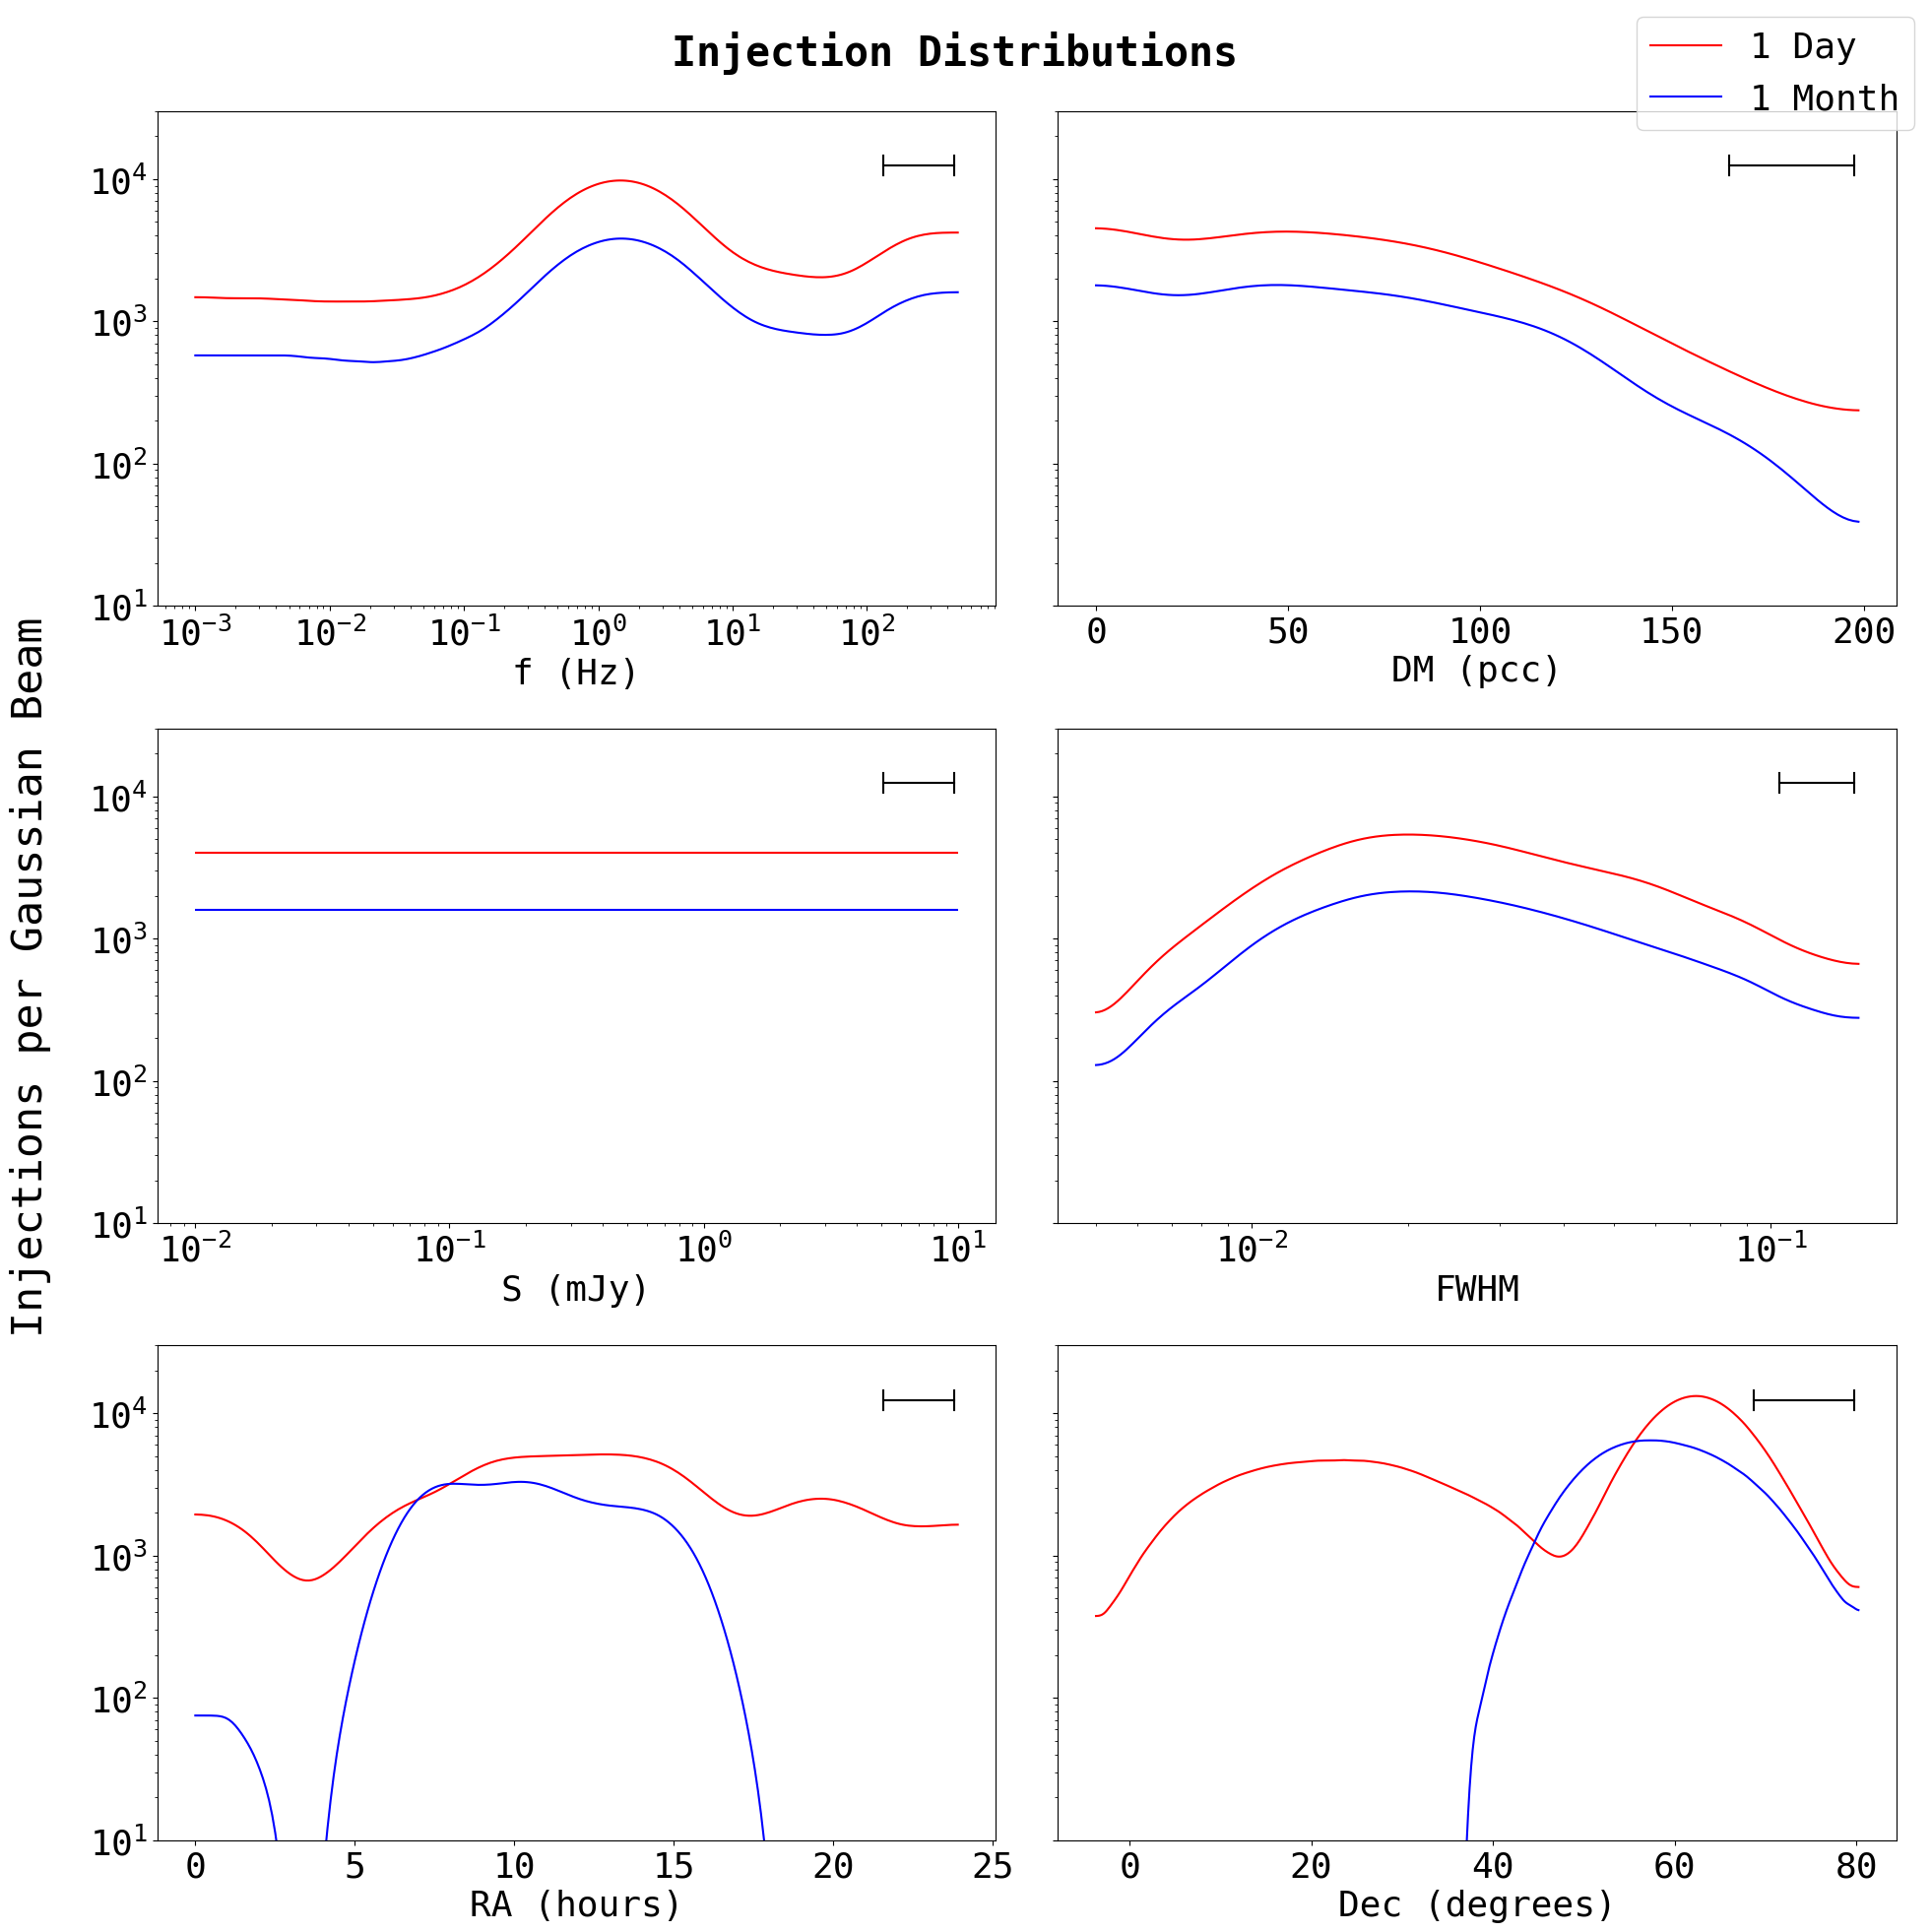

In [336]:
fig, ax = plt.subplots(3, 2, figsize=(20, 20), sharey = True, layout = 'constrained')
ax = ax.flatten()

ax[0].plot(f_bins[:-1], gaussian_filter(f_inj_p_smooth, 3), color='red', label='1 Day')
ax[0].plot(f_bins[:-1], gaussian_filter(f_inj_p_30, 3), color='blue', label='1 Month')
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_ylim(1e1, 3e4)
ax[0].set_xlabel('f (Hz)')
au.add_crosshair(ax[0], f_bins, np.sqrt(f_dev**2 + 3**2))

ax[1].plot(DM_bins[:-1], gaussian_filter(DM_inj_p_smooth, 10), color='red')
ax[1].plot(DM_bins[:-1], gaussian_filter(DM_inj_p_30, 10), color='blue')
#ax[1].plot(DM_bins, dm_distribution(DM_bins, 24, 24, 0.02) / max(DM_inj_p_smooth), color = 'black')
ax[1].set_xlabel('DM (pcc)')
au.add_crosshair(ax[1], DM_bins, np.sqrt(DM_dev**2 + 10**2))

#ax[2].plot(S_bins[:-1], S_inj_p_smooth, color='black', label='Actual')
#beam_area = np.sqrt(2 * np.pi) * S_dev
ax[2].hlines(np.mean(S_inj_p_smooth), 
             S_bins[0], S_bins[-1], color = 'red')
ax[2].hlines(np.mean(S_inj_p_30), 
             S_bins[0], S_bins[-1], color = 'blue')
ax[2].set_xscale('log')
ax[2].set_xlabel('S (mJy)')
au.add_crosshair(ax[2], S_bins, np.sqrt(S_dev**2 + 3**2))

ax[3].plot(FWHM_bins[:-1], gaussian_filter(FWHM_inj_p_smooth, 5), color='red')
ax[3].plot(FWHM_bins[:-1], gaussian_filter(FWHM_inj_p_30, 5), color='blue')
ax[3].set_xscale('log')
ax[3].set_xlabel('FWHM')
au.add_crosshair(ax[3], FWHM_bins, np.sqrt(FWHM_dev**2 + 5**2))

ax[4].plot(RA_bins[:-1] / 15, gaussian_filter(RA_inj_p_smooth, 3), color='red')
ax[4].plot(RA_bins[:-1] / 15, gaussian_filter(RA_inj_p_30, 3), color='blue')
ax[4].set_xlabel('RA (hours)')
au.add_crosshair(ax[4], RA_bins, np.sqrt(RA_dev**2 + 3**2))

ax[5].plot(Dec_bins[:-1], gaussian_filter(Dec_inj_p_smooth, 3), color='red')
ax[5].plot(Dec_bins[:-1], gaussian_filter(Dec_inj_p_30, 3), color='blue')
ax[5].set_xlabel('Dec (degrees)')
au.add_crosshair(ax[5], Dec_bins, np.sqrt(Dec_dev**2 + 3**2))

fig.suptitle('Injection Distributions', fontsize=30, fontweight='bold')
fig.supylabel('Injections per Gaussian Beam')
fig.legend()
#handles, labels = ax[0].get_legend_handles_labels()
# fig.legend(handles, labels, title='Harmonics Counted', loc='upper right',
#            bbox_to_anchor=(1.0, 1.0), bbox_transform=fig.transFigure)
plt.tight_layout()

/tmp/ipykernel_2132545/22652855.py:58: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


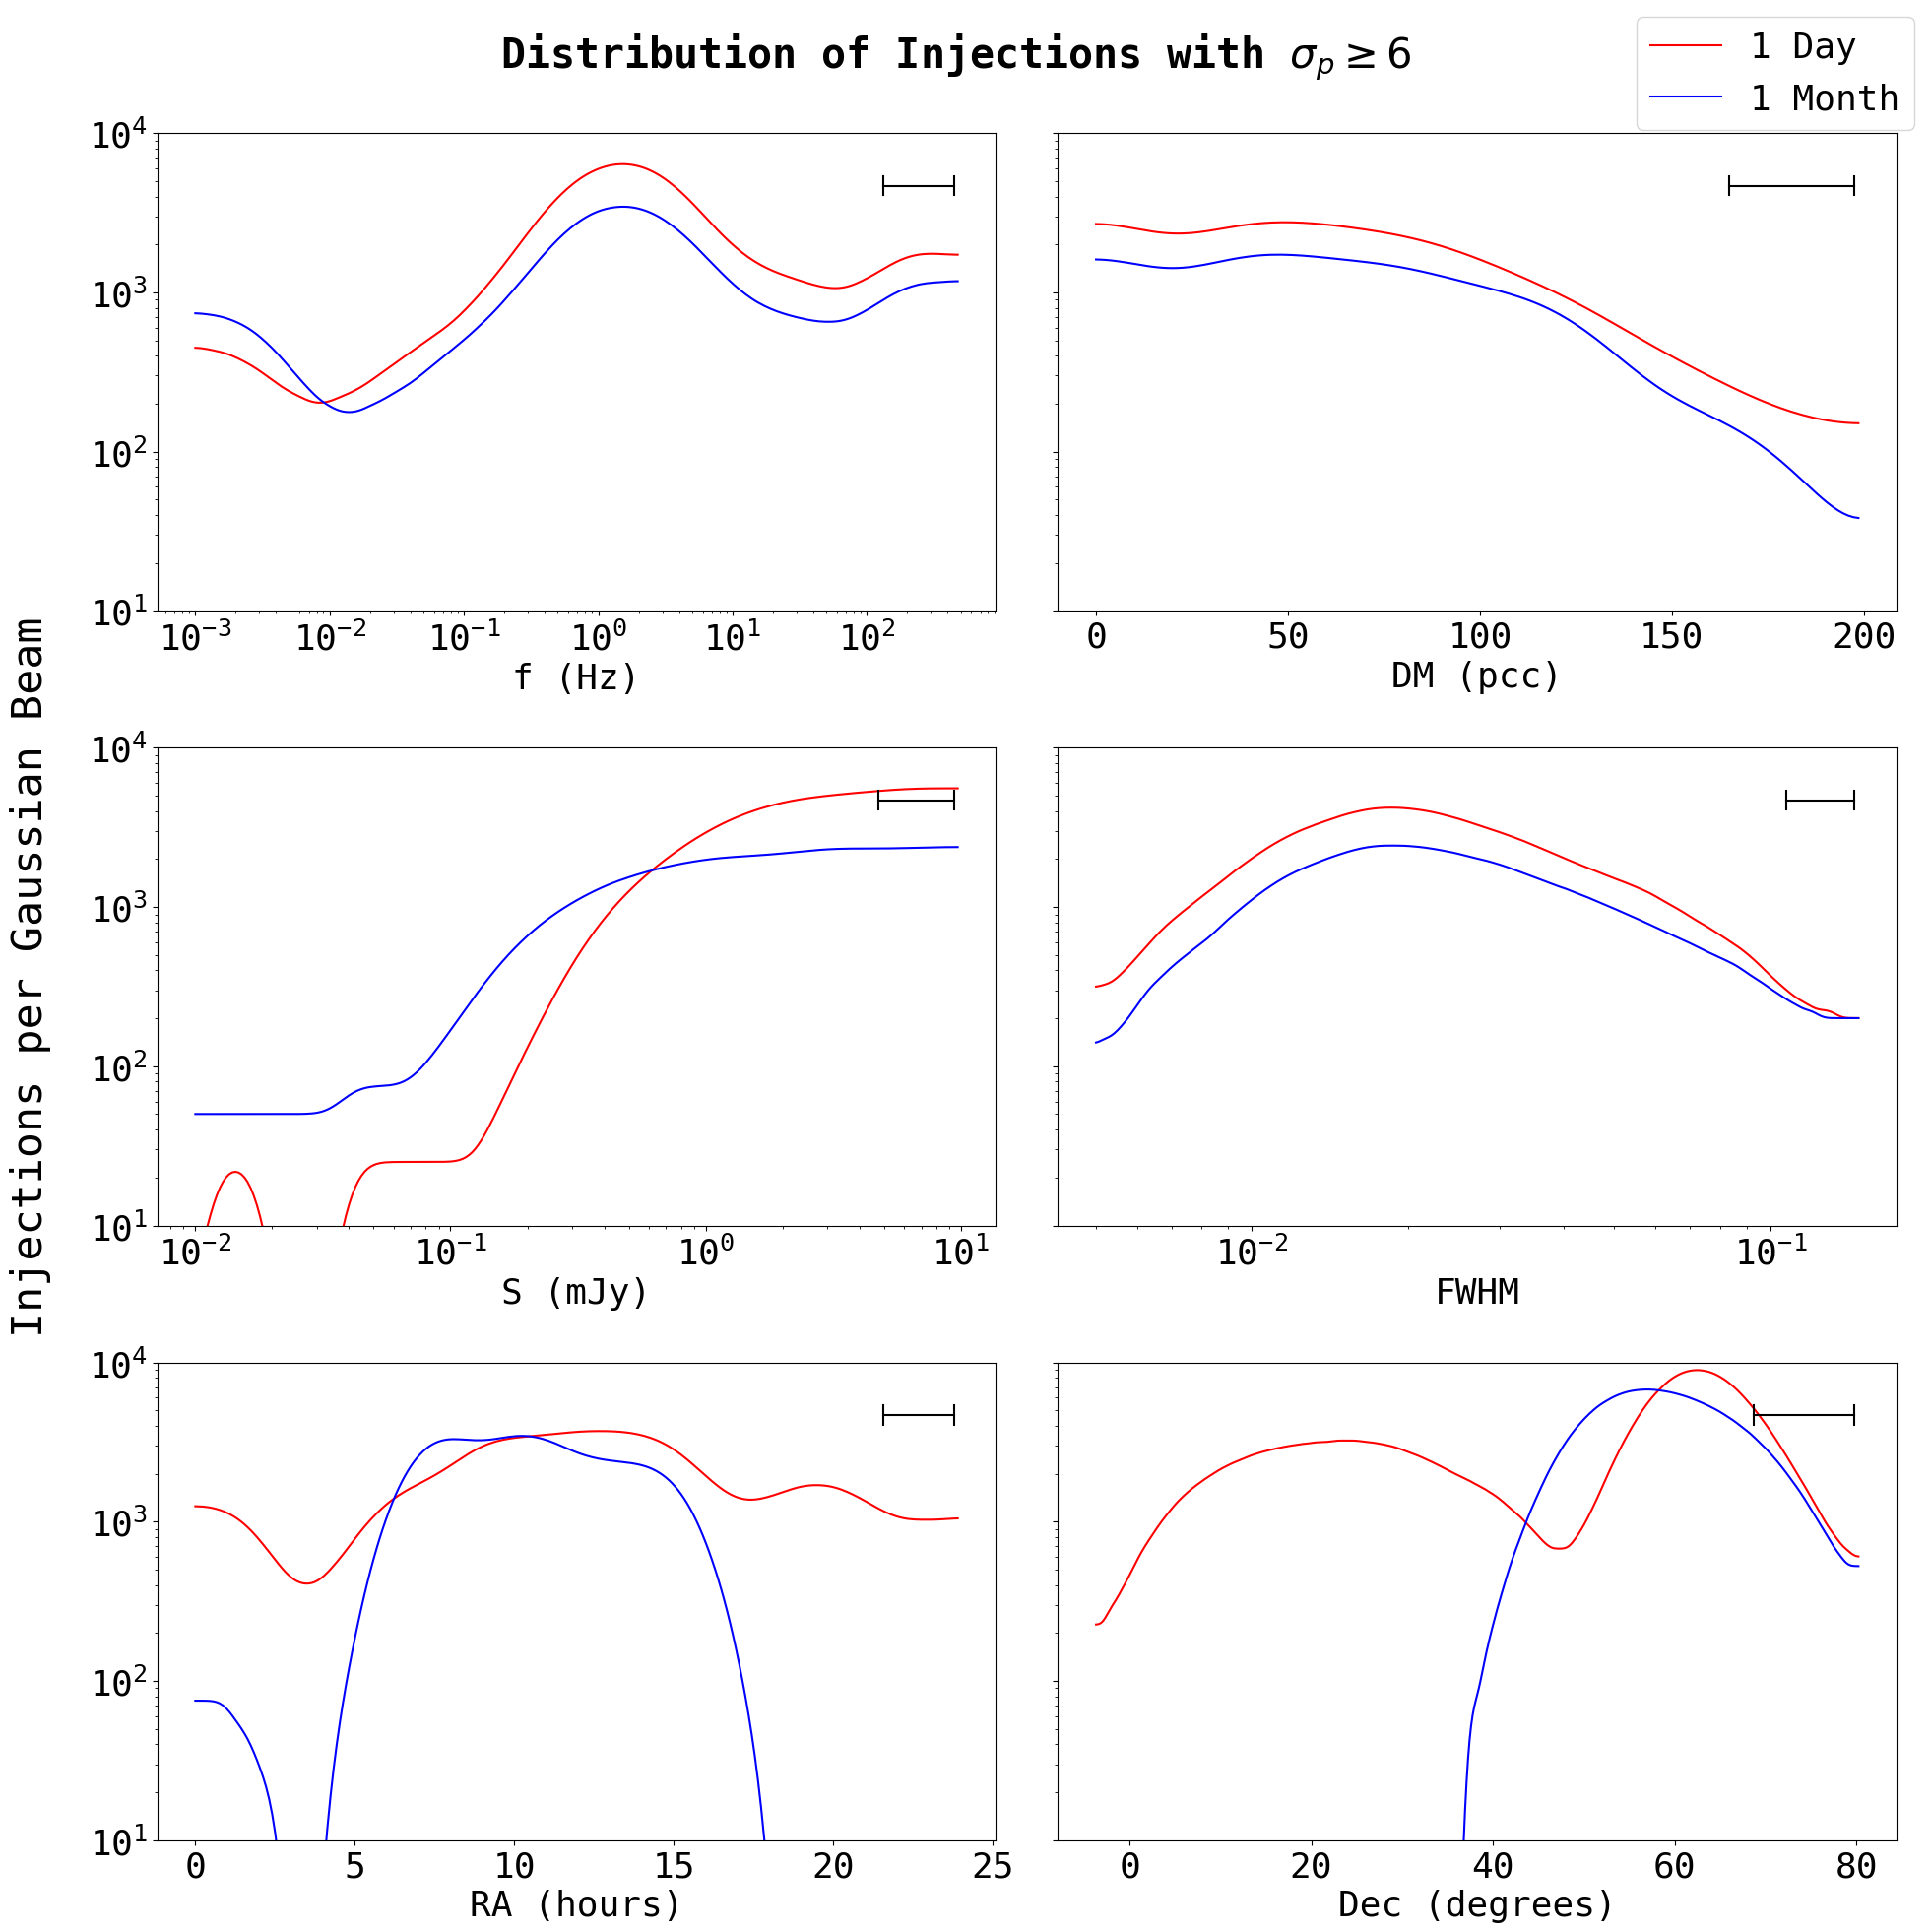

In [337]:
sigma_mask_1 = data_1[:, sigma_idx] > 6
sigma_mask_30 = data_stack[: sigma_idx] > 6



fig, ax = plt.subplots(3, 2, figsize=(20, 20), sharey = True, layout = 'constrained')
ax = ax.flatten()

ax[0].plot(f_bins[:-1], gaussian_filter(f_sigma_1, 3), color='red', label='1 Day')
ax[0].plot(f_bins[:-1], gaussian_filter(f_sigma_30, 3), color='blue', label='1 Month')
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_xlabel('f (Hz)')
au.add_crosshair(ax[0], f_bins, np.sqrt(f_dev**2 + 3**2))

ax[1].plot(DM_bins[:-1], gaussian_filter(DM_sigma_1, 10), color='red')
ax[1].plot(DM_bins[:-1], gaussian_filter(DM_sigma_30, 10), color='blue')
#ax[1].plot(DM_bins, dm_distribution(DM_bins, 24, 24, 0.02) / max(DM_inj_p_smooth), color = 'black')
ax[1].set_xlabel('DM (pcc)')
ax[1].set_yscale('log')
au.add_crosshair(ax[1], DM_bins, np.sqrt(DM_dev**2 + 10**2))

#ax[2].plot(S_bins[:-1], S_inj_p_smooth, color='black', label='Actual')
#beam_area = np.sqrt(2 * np.pi) * S_dev
ax[2].plot(S_bins[:-1], gaussian_filter(S_sigma_1, 5), color = 'red')
ax[2].plot(S_bins[:-1], gaussian_filter(S_sigma_30, 5), color = 'blue')
ax[2].set_xscale('log')
ax[2].set_xlabel('S (mJy)')
ax[2].set_yscale('log')
au.add_crosshair(ax[2], S_bins, np.sqrt(S_dev**2 + 5**2))

ax[3].plot(FWHM_bins[:-1], gaussian_filter(FWHM_sigma_1, 2), color='red')
ax[3].plot(FWHM_bins[:-1], gaussian_filter(FWHM_sigma_30, 2), color='blue')
ax[3].set_xscale('log')
ax[3].set_xlabel('FWHM')
ax[3].set_yscale('log')
au.add_crosshair(ax[3], FWHM_bins, np.sqrt(FWHM_dev**2 + 2**2))

ax[4].plot(RA_bins[:-1] / 15, gaussian_filter(RA_sigma_1, 3), color='red')
ax[4].plot(RA_bins[:-1] / 15, gaussian_filter(RA_sigma_30, 3), color='blue')
ax[4].set_xlabel('RA (hours)')
ax[4].set_yscale('log')
au.add_crosshair(ax[4], RA_bins, np.sqrt(RA_dev**2 + 3**2))

ax[5].plot(Dec_bins[:-1], gaussian_filter(Dec_sigma_1, 3), color='red')
ax[5].plot(Dec_bins[:-1], gaussian_filter(Dec_sigma_30, 3), color='blue')
ax[5].set_xlabel('Dec (degrees)')
ax[5].set_yscale('log')
au.add_crosshair(ax[5], Dec_bins, np.sqrt(Dec_dev**2 + 3**2))
ax[5].set_ylim(1e1, 1e4)

fig.suptitle(r'Distribution of Injections with $\sigma_p \geq 6$', fontsize=30, fontweight='bold')
fig.supylabel('Injections per Gaussian Beam')
#handles, labels = ax[0].get_legend_handles_labels()
# fig.legend(handles, labels, title='Harmonics Counted', loc='upper right',
#            bbox_to_anchor=(1.0, 1.0), bbox_transform=fig.transFigure)
fig.legend()
plt.tight_layout()

In [338]:
importlib.reload(au)

<module 'scripts.analysis_utils' from '/data1/people/rsquillace/Transmissivity/scripts/analysis_utils.py'>

/tmp/ipykernel_2132545/205195723.py:73: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


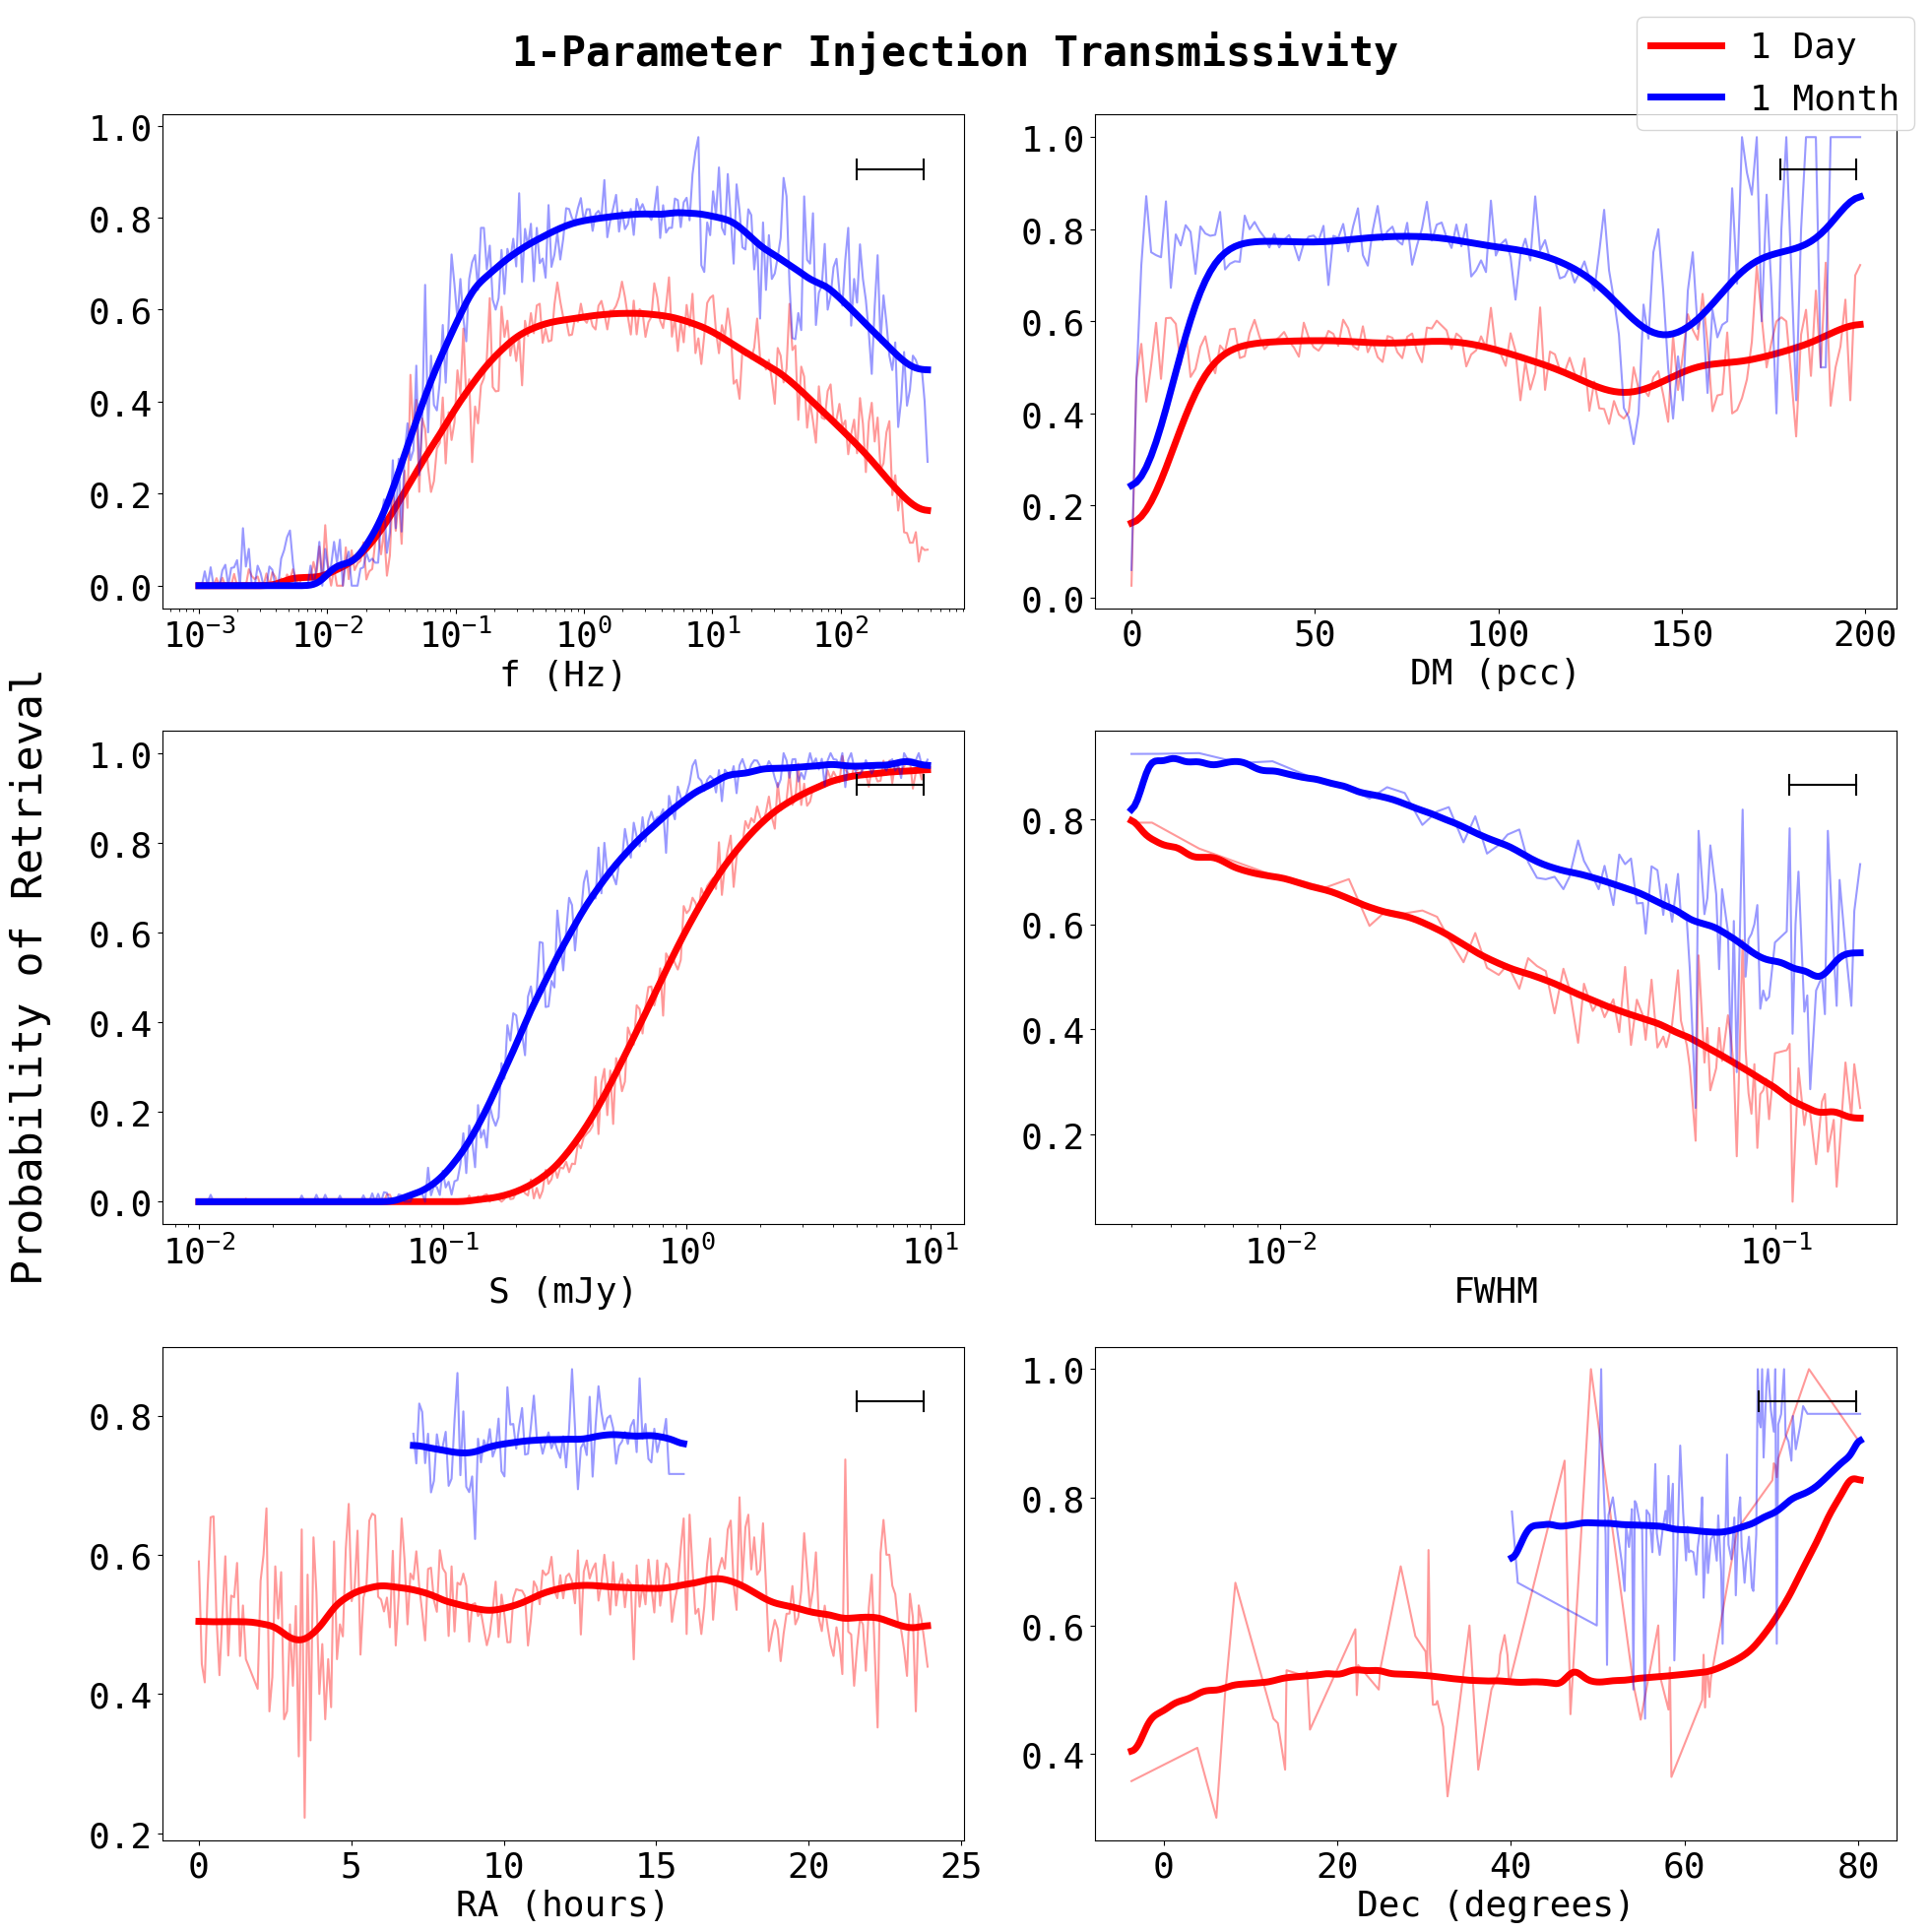

In [365]:
fig, ax = plt.subplots(3, 2, figsize=(20, 20), layout = 'constrained')
ax = ax.flatten()
ax[0].plot(f_bins[:-1], gaussian_filter(f_sens_smooth, 3), color='red', 
           label='1 Day', linewidth = '5.')
ax[0].plot(f_bins[:-1], f_sens, alpha=0.4, color='red')
ax[0].plot(f_bins[:-1], gaussian_filter(f_sens_smooth_30, 3), color='blue', 
           label='1 Month', linewidth = '5.')
ax[0].plot(f_bins[:-1], f_sens_30, alpha=0.4, color='blue')
ax[0].set_xscale('log')
ax[0].set_xlabel('f (Hz)')
au.add_crosshair(ax[0], f_bins, np.sqrt(f_dev**2 + 3**2))

ax[1].plot(DM_bins[:-1], gaussian_filter(DM_sens_smooth, 5), color='red', linewidth = '5.')
ax[1].plot(DM_bins[:-1], DM_sens, alpha=0.4, color='red')
ax[1].plot(DM_bins[:-1], gaussian_filter(DM_sens_smooth_30, 5), color='blue', linewidth = '5.')
ax[1].plot(DM_bins[:-1], DM_sens_30, alpha=0.4, color='blue')
#ax[1].plot(DM_bins[:-1], gaussian_filter(DM_pred_smooth, 5), 'k--')
# ax[1].plot(DM_bins[:-1], gaussian_filter(DM_comp_smooth, 3), color='blue')
# ax[1].plot(DM_bins[:-1], DM_comp, alpha=0.4, color='blue')
ax[1].set_xlabel('DM (pcc)')
au.add_crosshair(ax[1], DM_bins, np.sqrt(DM_dev**2 + 5**2))

ax[2].plot(S_bins[:-1], gaussian_filter(S_sens_smooth, 3), color='red', linewidth = '5.')
ax[2].plot(S_bins[:-1], S_sens, alpha=0.4, color='red')
ax[2].plot(S_bins[:-1], gaussian_filter(S_sens_smooth_30, 3), color='blue', linewidth = '5.')
ax[2].plot(S_bins[:-1], S_sens_30, alpha=0.4, color='blue')
# ax[2].plot(S_bins[:-1], gaussian_filter(S_comp_smooth, 3), color='blue')
# ax[2].plot(S_bins[:-1], S_comp, alpha=0.4, color='blue')
ax[2].set_xscale('log')
ax[2].set_xlabel('S (mJy)')
au.add_crosshair(ax[2], S_bins, np.sqrt(S_dev**2 + 3**2))

ax[3].plot(FWHM_bins[:-1], gaussian_filter(FWHM_sens_smooth, 3), color='red', linewidth = '5.')
ax[3].plot(FWHM_bins[:-1], FWHM_sens, alpha=0.4, color='red')
ax[3].plot(FWHM_bins[:-1], gaussian_filter(FWHM_sens_smooth_30, 3), color='blue', linewidth = '5.')
ax[3].plot(FWHM_bins[:-1], FWHM_sens_30, alpha=0.4, color='blue')
# ax[3].plot(FWHM_bins[:-1], gaussian_filter(FWHM_comp_smooth, 3), color='blue')
# ax[3].plot(FWHM_bins[:-1], FWHM_comp, alpha=0.4, color='blue')
ax[3].set_xscale('log')
ax[3].set_xlabel('FWHM')
au.add_crosshair(ax[3], FWHM_bins, np.sqrt(FWHM_dev**2 + 3**2))

RA_mask = (RA_bins[:-1] > 7*15) & (RA_bins[:-1] < 16*15)
#RA_nanmask = RA_bins[:-1] < 7*15
#RA_sens_smooth_30[RA_nanmask] = np.nan
#RA_sens_30[RA_nanmask] = np.nan
ax[4].plot(RA_bins[:-1] / 15, gaussian_filter(RA_sens_smooth, 3), color='red', linewidth = '5.')
ax[4].plot(RA_bins[:-1] / 15, RA_sens, alpha=0.4, color='red')
ax[4].plot(RA_bins[:-1][RA_mask] / 15, gaussian_filter(RA_sens_smooth_30[RA_mask], 3), color='blue', linewidth = '5.')
ax[4].plot(RA_bins[:-1][RA_mask] / 15, RA_sens_30[RA_mask], alpha=0.4, color='blue')
# ax[3].plot(RA_bins[:-1], gaussian_filter(RA_comp_smooth, 3), color='blue')
# ax[3].plot(RA_bins[:-1], RA_comp, alpha=0.4, color='blue')
ax[4].set_xlabel('RA (hours)')
au.add_crosshair(ax[4], RA_bins, np.sqrt(RA_dev**2 + 3**2))

Dec_mask = Dec_bins[:-1] > 40
ax[5].plot(Dec_bins[:-1], gaussian_filter(Dec_sens_smooth, 5), color='red', linewidth = '5.')
ax[5].plot(Dec_bins[:-1], Dec_sens, alpha=0.4, color='red')
ax[5].plot(Dec_bins[:-1][Dec_mask], gaussian_filter(Dec_sens_smooth_30[Dec_mask], 5), color='blue', linewidth = '5.')
ax[5].plot(Dec_bins[:-1][Dec_mask], Dec_sens_30[Dec_mask], alpha=0.4, color='blue')
# ax[3].plot(Dec_bins[:-1], gaussian_filter(Dec_comp_smooth, 3), color='blue')
# ax[3].plot(Dec_bins[:-1], Dec_comp, alpha=0.4, color='blue')
ax[5].set_xlabel('Dec (degrees)')
au.add_crosshair(ax[5], Dec_bins, np.sqrt(Dec_dev**2 + 5**2))

fig.suptitle('1-Parameter Injection Transmissivity', fontsize=30, fontweight='bold')
fig.supylabel('Probability of Retrieval')
#fig.legend()
handles, labels = ax[0].get_legend_handles_labels()
fig.legend()
# fig.legend(handles, labels, title='Harmonics Counted', loc='upper right',
#            bbox_to_anchor=(1.0, 1.0), bbox_transform=fig.transFigure)
plt.tight_layout()

/tmp/ipykernel_2132545/2205129884.py:73: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


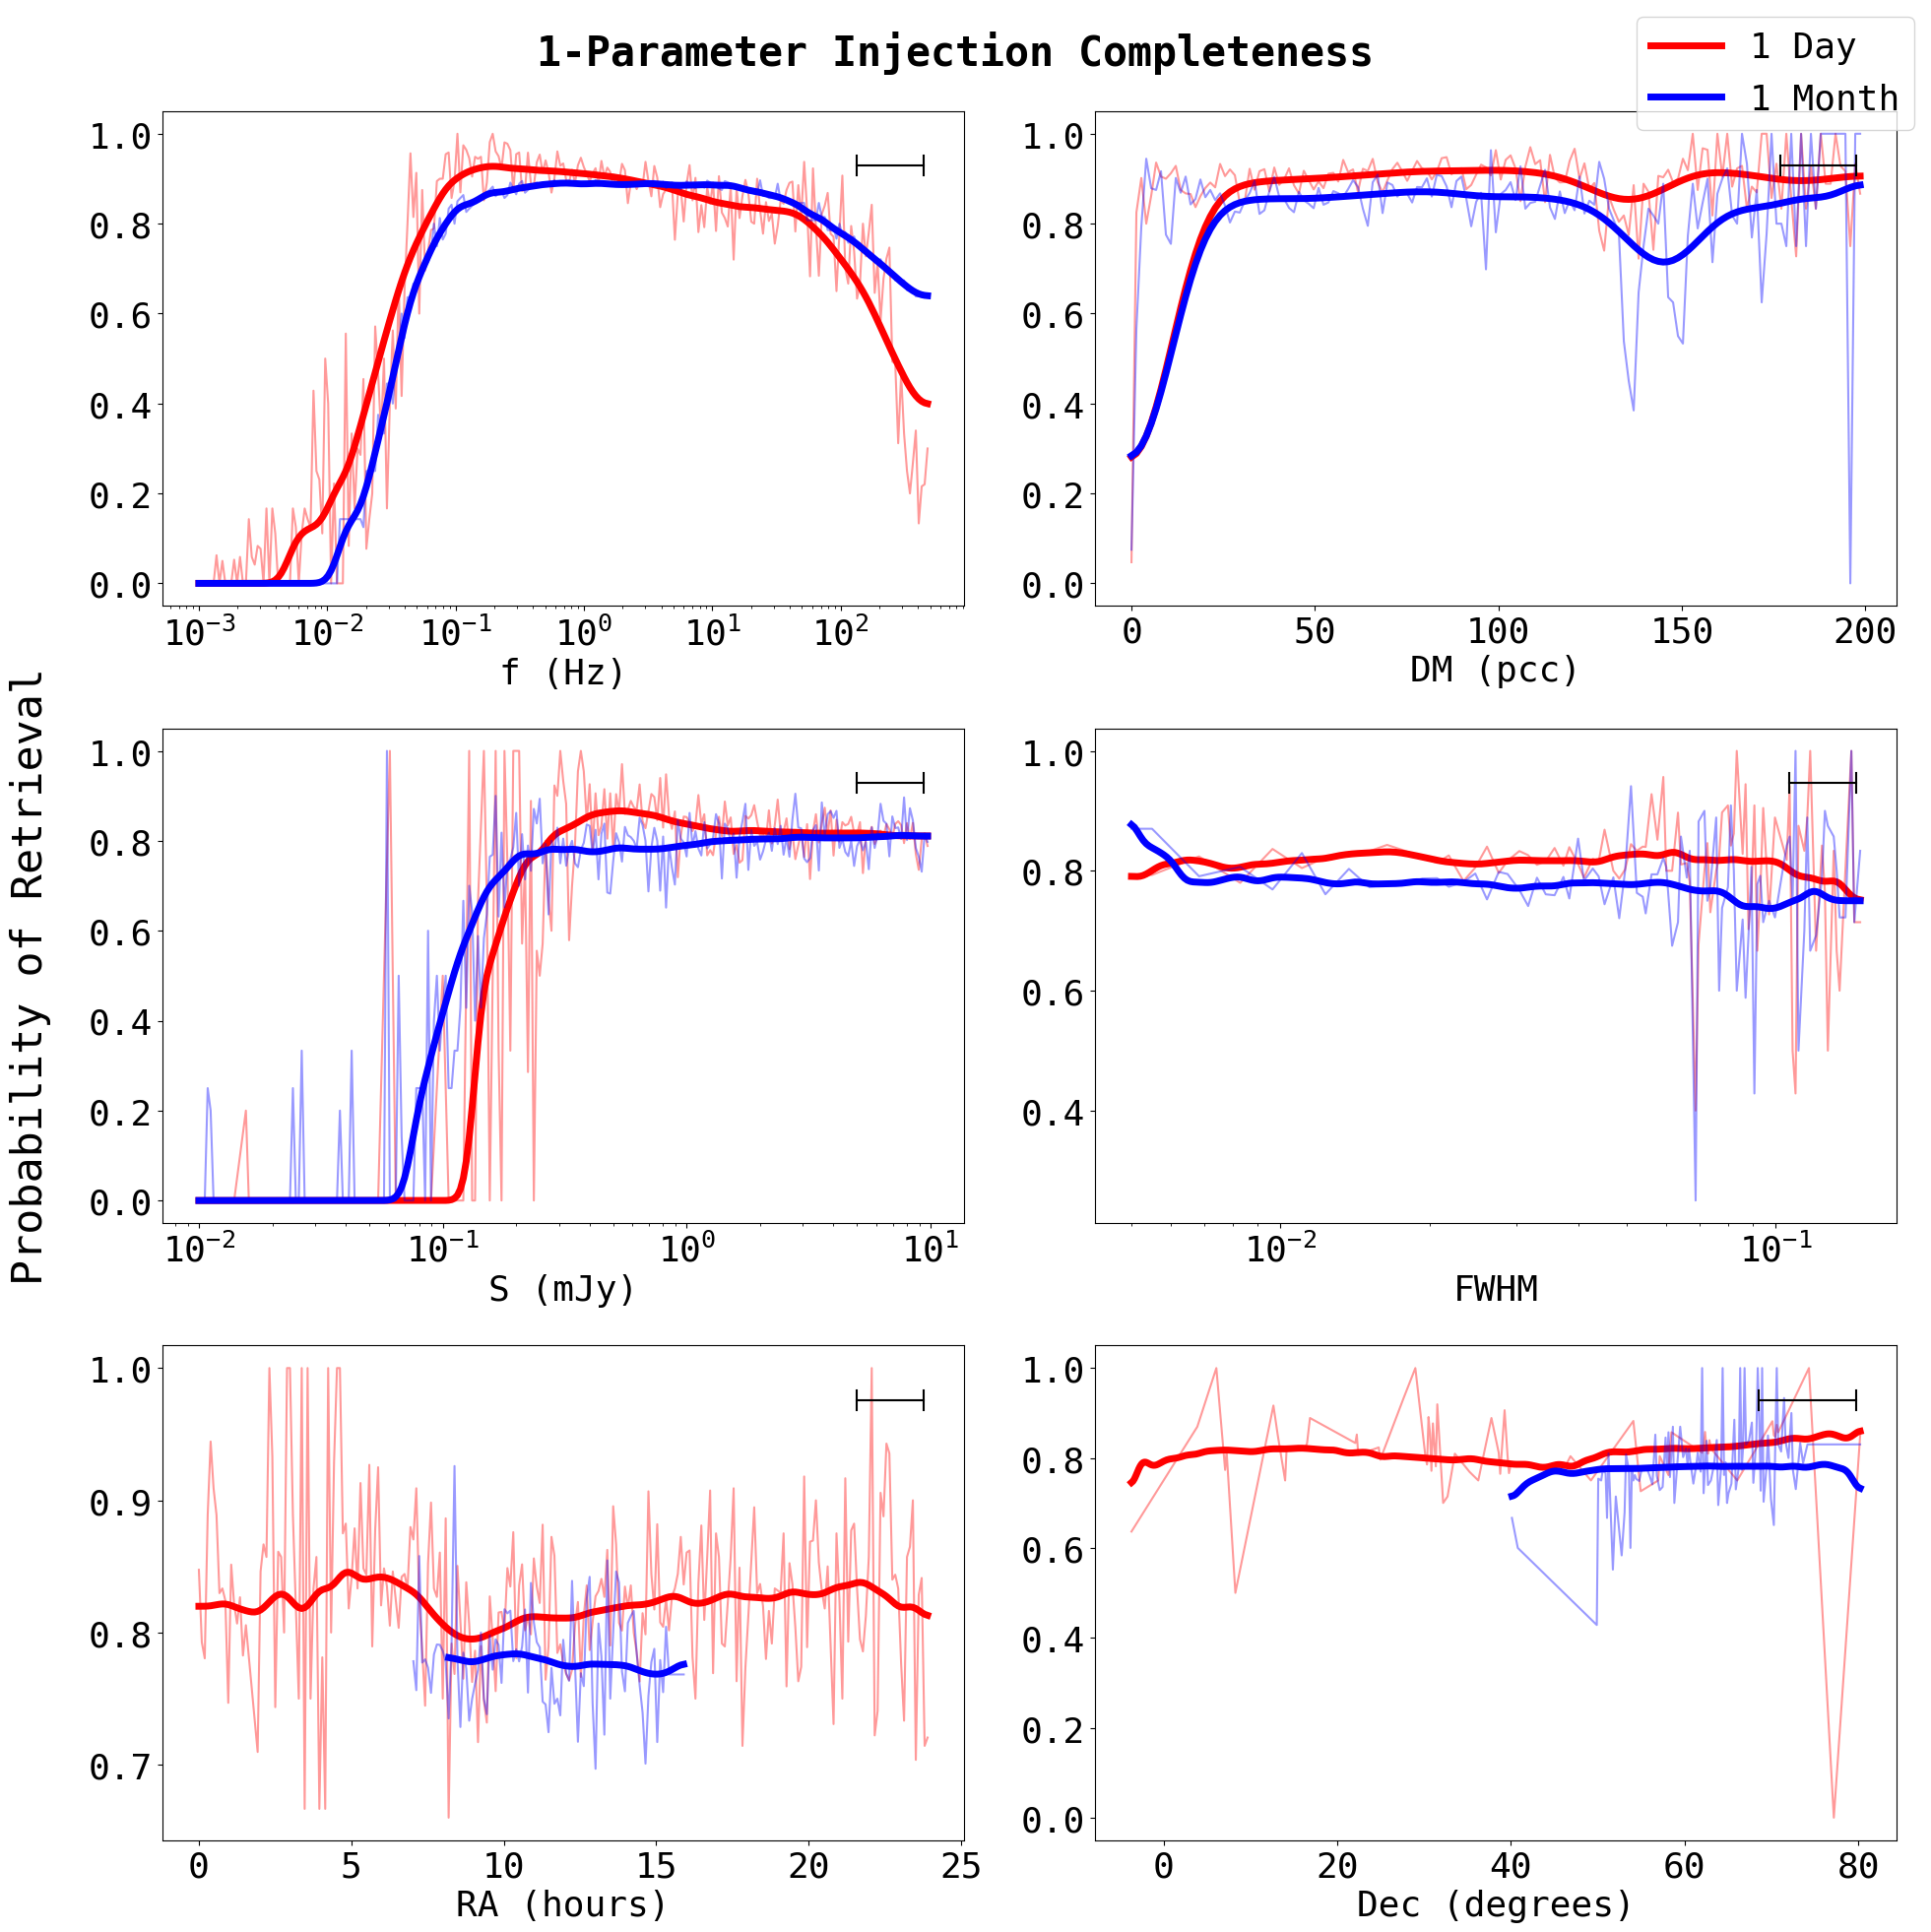

In [356]:
fig, ax = plt.subplots(3, 2, figsize=(20, 20), layout = 'constrained')
ax = ax.flatten()
ax[0].plot(f_bins[:-1], gaussian_filter(f_comp_smooth, 3), color='red', 
           label='1 Day', linewidth = '5.')
ax[0].plot(f_bins[:-1], f_comp, alpha=0.4, color='red')
ax[0].plot(f_bins[:-1], gaussian_filter(f_comp_30, 3), color='blue', 
           label='1 Month', linewidth = '5.')
ax[0].plot(f_bins[:-1], f_comp_30, alpha=0.4, color='blue')
ax[0].set_xscale('log')
ax[0].set_xlabel('f (Hz)')
au.add_crosshair(ax[0], f_bins, np.sqrt(f_dev**2 + 3**2))

ax[1].plot(DM_bins[:-1], gaussian_filter(DM_comp_smooth, 5), color='red', linewidth = '5.')
ax[1].plot(DM_bins[:-1], DM_comp, alpha=0.4, color='red')
ax[1].plot(DM_bins[:-1], gaussian_filter(DM_comp_smooth_30, 5), color='blue', linewidth = '5.')
ax[1].plot(DM_bins[:-1], DM_comp_30, alpha=0.4, color='blue')
#ax[1].plot(DM_bins[:-1], gaussian_filter(DM_pred_smooth, 5), 'k--')
# ax[1].plot(DM_bins[:-1], gaussian_filter(DM_comp_smooth, 3), color='blue')
# ax[1].plot(DM_bins[:-1], DM_comp, alpha=0.4, color='blue')
ax[1].set_xlabel('DM (pcc)')
au.add_crosshair(ax[1], DM_bins, np.sqrt(DM_dev**2 + 5**2))

ax[2].plot(S_bins[:-1], gaussian_filter(S_comp_smooth, 3), color='red', linewidth = '5.')
ax[2].plot(S_bins[:-1], S_comp, alpha=0.4, color='red')
ax[2].plot(S_bins[:-1], gaussian_filter(S_comp_smooth_30, 3), color='blue', linewidth = '5.')
ax[2].plot(S_bins[:-1], S_comp_30, alpha=0.4, color='blue')
# ax[2].plot(S_bins[:-1], gaussian_filter(S_comp_smooth, 3), color='blue')
# ax[2].plot(S_bins[:-1], S_comp, alpha=0.4, color='blue')
ax[2].set_xscale('log')
ax[2].set_xlabel('S (mJy)')
au.add_crosshair(ax[2], S_bins, np.sqrt(S_dev**2 + 3**2))

ax[3].plot(FWHM_bins[:-1], gaussian_filter(FWHM_comp_smooth, 3), color='red', linewidth = '5.')
ax[3].plot(FWHM_bins[:-1], FWHM_comp, alpha=0.4, color='red')
ax[3].plot(FWHM_bins[:-1], gaussian_filter(FWHM_comp_smooth_30, 3), color='blue', linewidth = '5.')
ax[3].plot(FWHM_bins[:-1], FWHM_comp_30, alpha=0.4, color='blue')
# ax[3].plot(FWHM_bins[:-1], gaussian_filter(FWHM_comp_smooth, 3), color='blue')
# ax[3].plot(FWHM_bins[:-1], FWHM_comp, alpha=0.4, color='blue')
ax[3].set_xscale('log')
ax[3].set_xlabel('FWHM')
au.add_crosshair(ax[3], FWHM_bins, np.sqrt(FWHM_dev**2 + 3**2))

RA_mask = RA_bins[:-1] < 16*15
RA_nanmask = RA_bins[:-1] < 7*15
RA_comp_smooth_30[RA_nanmask] = np.nan
RA_comp_30[RA_nanmask] = np.nan
ax[4].plot(RA_bins[:-1] / 15, gaussian_filter(RA_comp_smooth, 3), color='red', linewidth = '5.')
ax[4].plot(RA_bins[:-1] / 15, RA_comp, alpha=0.4, color='red')
ax[4].plot(RA_bins[:-1][RA_mask] / 15, gaussian_filter(RA_comp_smooth_30[RA_mask], 3), color='blue', linewidth = '5.')
ax[4].plot(RA_bins[:-1][RA_mask] / 15, RA_comp_30[RA_mask], alpha=0.4, color='blue')
# ax[3].plot(RA_bins[:-1], gaussian_filter(RA_comp_smooth, 3), color='blue')
# ax[3].plot(RA_bins[:-1], RA_comp, alpha=0.4, color='blue')
ax[4].set_xlabel('RA (hours)')
au.add_crosshair(ax[4], RA_bins, np.sqrt(RA_dev**2 + 3**2))

Dec_mask = Dec_bins[:-1] > 40
ax[5].plot(Dec_bins[:-1], gaussian_filter(Dec_comp_smooth, 5), color='red', linewidth = '5.')
ax[5].plot(Dec_bins[:-1], Dec_comp, alpha=0.4, color='red')
ax[5].plot(Dec_bins[:-1][Dec_mask], gaussian_filter(Dec_comp_smooth_30[Dec_mask], 5), color='blue', linewidth = '5.')
ax[5].plot(Dec_bins[:-1][Dec_mask], Dec_comp_30[Dec_mask], alpha=0.4, color='blue')
# ax[3].plot(Dec_bins[:-1], gaussian_filter(Dec_comp_smooth, 3), color='blue')
# ax[3].plot(Dec_bins[:-1], Dec_comp, alpha=0.4, color='blue')
ax[5].set_xlabel('Dec (degrees)')
au.add_crosshair(ax[5], Dec_bins, np.sqrt(Dec_dev**2 + 5**2))

fig.suptitle('1-Parameter Injection Completeness', fontsize=30, fontweight='bold')
fig.supylabel('Probability of Retrieval')
#fig.legend()
handles, labels = ax[0].get_legend_handles_labels()
fig.legend()
# fig.legend(handles, labels, title='Harmonics Counted', loc='upper right',
#            bbox_to_anchor=(1.0, 1.0), bbox_transform=fig.transFigure)
plt.tight_layout()

In [367]:
print('Paramter Standard Deviation')
RA_zero_mask = RA_sens_smooth_30 == 0.
Dec_zero_mask = Dec_sens_smooth_30 == 0.
print(f'Frequency: {(f_sens_smooth.max() - f_sens_smooth.min()):.2f}/{(f_sens_smooth_30.max() - f_sens_smooth_30.min()):.2f}')
print(f'DM: {(DM_sens_smooth.max() - DM_sens_smooth.min()):.2f}/{(DM_sens_smooth_30.max() - DM_sens_smooth_30.min()):.2f}')
print(f'Flux: {(S_sens_smooth.max() - S_sens_smooth.min()):.2f}/{(S_sens_smooth_30.max() - S_sens_smooth_30.min()):.2f}')
print(f'FWHM: {(FWHM_sens_smooth.max() - FWHM_sens_smooth.min()):.2f}/{(FWHM_sens_smooth_30.max() - FWHM_sens_smooth_30.min()):.2f}')
print(f'RA: {(RA_sens_smooth.max() - RA_sens_smooth.min()):.2f}/{(RA_sens_smooth_30[RA_mask].max() - RA_sens_smooth_30[RA_mask].min()):.2f}')
print(f'Dec: {(Dec_sens_smooth.max() - Dec_sens_smooth.min()):.2f}/{(gaussian_filter(Dec_sens_smooth_30[Dec_mask], 5).max() - gaussian_filter(Dec_sens_smooth_30[Dec_mask], 5).min()):.2f}')

Paramter Standard Deviation
Frequency: 0.59/0.82
DM: 0.53/0.84
Flux: 0.96/0.99
FWHM: 0.60/0.54
RA: 0.11/0.04
Dec: 0.56/0.18
